SOW-BKI230A Deep Learning<br>2025

Assignment 1<br>Preliminaries

**Name:**

Angelina

**S-number:**

s1125886

# 📖 Autodiff Assignment: Implementing Automatic Differentiation

**Goal:** Implement a simple automatic differentiation mechanism using a decorator-based `Variable` class.

**Learning Outcomes:**

1.  **Forward Pass:** Understand how an operation's output (data) and local derivatives (edge) are computed.
2.  **Decorator Pattern:** Learn how to wrap arithmetic operations to return new `Variable` instances.
3.  **Backward Pass:** Implement gradient propagation recursively using the chain rule.
4.  **Gradient Reset:** Understand why and how to reset gradients (`zero_grad`) before performing multiple backward passes.






## 📌 Understanding Local Gradients (Q1)

Before writing any code, derive the local gradients for each operation. For two scalars _x_ and _y_, the table below can guide your derivation:

| Operation               | Forward Pass (_z_) | ∂*z*/∂*x* | ∂*z*/∂*y* |
| :---------------------- | :----------------- | :-------: | :-------: |
| _z_ = _x_ + _y_         | _x_ + _y_          |     1     |     1     |
| _z_ = _x_ - _y_         | _x_ - _y_          |     1     |     -1     |
| _z_ = _x_ \* _y_        | _x_ \* _y_         |     y     |     x     |
| _z_ = _x_ / _y_         | _x_ / _y_          |     1/y     |     -x/y<sup>2     |
| _z_ = _x_<sup>_y_</sup> | _x_<sup>_y_</sup>  |     yx<sup>(y-1)     |     ln(x)*x<sup>y     |

## Starter Code

In [ ]:
import math

class Variable:
    def __init__(self, data: float, edge=(), node=()):
        """
        Initialize a Variable object.

        Args:
            data (float): The value of the variable.
            edge (tuple, optional): Local derivatives with respect to the parents.
            node (tuple, optional): The parent nodes that created this variable.
        """
        self.data = float(data)  # Ensure data is a float
        self.edge = edge         # Local derivatives (computed during forward pass)
        self.node = node         # Parent nodes
        self.grad = 0.0          # Initialize gradient to zero

    def __repr__(self):
        """
        Return a string representation of the Variable, showing both value and gradient.
        """
        return f"Variable(data={self.data}, grad={self.grad})"

    def decorate(operator):
        """
        Decorator to handle the forward pass for all operations.

        This decorator takes an operator function (e.g., __add__, __mul__) as input
        and returns a new function that:

        1. Calls the operator function with self and other (making sure 'other' is a Variable).
        2. Collects the returned (data, edge, node) from the operator function.
        3. Creates and returns a new Variable object with the computed data, edge, and node. #знач перменой, локал производ по родительски узлам, род узлы(из них получена текущ перемен)
        """
        def wrapper(self, other):
            other = other if isinstance(other, self.__class__) else self.__class__(other)
            return self.__class__(*operator(self, other))
        return wrapper

    @decorate
    def __add__(self, other):
        """
        Implement the addition operation (+).

        Returns:
            data, edge, node
        """
        # YOUR CODE HERE (Q2)
        data = self.data + other.data  # Replace with the correct forward pass calculation
        edge = (1, 1)  # Replace with local derivatives
        node = (self, other)
        return data, edge, node

    @decorate
    def __sub__(self, other):
        """
        Implement the subtraction operation (-).

        Returns:
            data, edge, node
        """
        # YOUR CODE HERE (Q3)
        data = self.data - other.data  # Replace with the correct forward pass calculation
        edge = (1, -1)  # Replace with local derivatives
        node = (self, other)
        return data, edge, node

    @decorate
    def __mul__(self, other):
        """
        Implement the multiplication operation (*).

        Returns:
            data, edge, node
        """
        # YOUR CODE HERE (Q4)
        data = self.data * other.data  # Replace with the correct forward pass calculation
        edge = (other.data, self.data)  # Replace with local derivatives
        node = (self, other)
        return data, edge, node

    @decorate
    def __truediv__(self, other):
        """
        Implement the true division operation (/).

        Returns:
            data, edge, node
        """
        # YOUR CODE HERE (Q5)
        data = self.data / other.data  # Replace with the correct forward pass calculation
        edge = ((1/other.data), (-self.data/other.data**2))  # Replace with local derivatives
        node = (self, other)
        return data, edge, node

    @decorate
    def __pow__(self, other):
        """
        Implement the power operation (**).

        Returns:
            data, edge, node
        """
        # YOUR CODE HERE (Q4)
        data = self.data  ** other.data  # Replace with the correct forward pass calculation
        edge = ((other.data*self.data**(other.data-1)), (self.data**(other.data) *math.log(self.data)))  # math.log(x, base) -> base by default = e
        node = (self, other)
        return data, edge, node

    # ------------------------
    # Reverse Operations
    # ------------------------
    def __radd__(self, other): return self.__add__(other)
    def __rsub__(self, other): return self.__class__(other).__sub__(self)
    def __rmul__(self, other): return self.__mul__(other)
    def __rtruediv__(self, other): return self.__class__(other).__truediv__(self)
    def __rpow__(self, other): return self.__class__(other).__pow__(self)

    def __neg__(self):
        """Enable usage of unary negative: e.g., -x."""
        return self.__mul__(-1) #mul by -1

    def backward(self, grad=1.0):
        """
        Implement the backward pass (recursive gradient calculation).

        Args:
            grad (float, optional): The incoming gradient from the subsequent
                                    nodes. Defaults to 1.0 for the final output node.

        Pseudo-Code:
            1. Accumulate the incoming gradient
            2. For each parent node:
                a. Compute the gradient contribution
                b. Call backward() recursively on the parent.
        """
        # YOUR CODE HERE (Q5)
        self.grad += grad #Accumulate the incoming gradient
        for parent, local_derivative in zip(self.node, self.edge):
          parent.backward(grad * local_derivative) #recursive call ->chain rule: (dz/dx) = grad(dz/dy) * deriv(dy/dx)(=local_grad)

    def zero_grad(self):
        """
        Resets gradients of the current node and all its parents to zero.
        Required for multiple backward passes on the same graph.

        Pseudo-Code:
            1. Reset accumulated gradient
            2. For each parent node recursively reset gradients
        """
        # YOUR CODE HERE (Q6)
        self.grad = 0.0
        for parent in self.node:
          parent.zero_grad()

## Example Usage / Tests

In [ ]:
# -------------------------
# Example Usage / Tests
# -------------------------

# Basic example
a = Variable(2.0)
b = Variable(3.0)

c = a + b   # c = 2 + 3 = 5
d = c * b   # d = 5 * 3 = 15
e = d ** 2  # e = 15^2 = 225

# Perform backward pass from e
e.backward()

print("---- After first backward pass ----")
print(f"a: {a}")  # Expect: a.grad = 90.0
print(f"b: {b}")  # Expect: b.grad = 240.0
print(f"c: {c}")  # Expect: c.grad = 90.0
print(f"d: {d}")  # Expect: d.grad = 30.0
print(f"e: {e}")  # Expect: e.grad = 1.0

# Test zero_grad
a.zero_grad()
b.zero_grad()
c.zero_grad()
d.zero_grad()
e.zero_grad()

print("\n---- After zero_grad() ----")
print(f"a: {a}")  # Expect: a.grad = 0.0
print(f"b: {b}")  # Expect: b.grad = 0.0
print(f"c: {c}")  # Expect: c.grad = 0.0
print(f"d: {d}")  # Expect: d.grad = 0.0
print(f"e: {e}")  # Expect: e.grad = 0.0

# Re-run backward() to see if gradients accumulate correctly
e.backward()

print("\n---- After second backward pass ----")
print(f"a: {a}")  # Expect: (a-b).grad = same as first
print(f"b: {b}")
print(f"c: {c}")
print(f"d: {d}")
print(f"e: {e}")

---- After first backward pass ----
a: Variable(data=2.0, grad=90.0)
b: Variable(data=3.0, grad=240.0)
c: Variable(data=5.0, grad=90.0)
d: Variable(data=15.0, grad=30.0)
e: Variable(data=225.0, grad=1.0)

---- After zero_grad() ----
a: Variable(data=2.0, grad=0.0)
b: Variable(data=3.0, grad=0.0)
c: Variable(data=5.0, grad=0.0)
d: Variable(data=15.0, grad=0.0)
e: Variable(data=225.0, grad=0.0)

---- After second backward pass ----
a: Variable(data=2.0, grad=90.0)
b: Variable(data=3.0, grad=240.0)
c: Variable(data=5.0, grad=90.0)
d: Variable(data=15.0, grad=30.0)
e: Variable(data=225.0, grad=1.0)


# Question 7

Consider the function $f(\mathbf{x}, \mathbf{w}, b) = \max(0, \mathbf{x} \mathbf{w}^T + b)$, where $\mathbf{x} = [x_1, x_2, x_3]$ and $\mathbf{w} = [w_1, w_2, w_3]$ are vectors and $b$ is a scalar.

**i)** Construct the computational grapf of $f(\mathbf{x}, \mathbf{w}, b)$ (Hint: See last slides of the lecture).

**ii)** Find $\frac{\partial f(\mathbf{x}, \mathbf{w}, b)}{\partial w_1}$ with forward-mode automatic differentiation.

**i) Answer:**
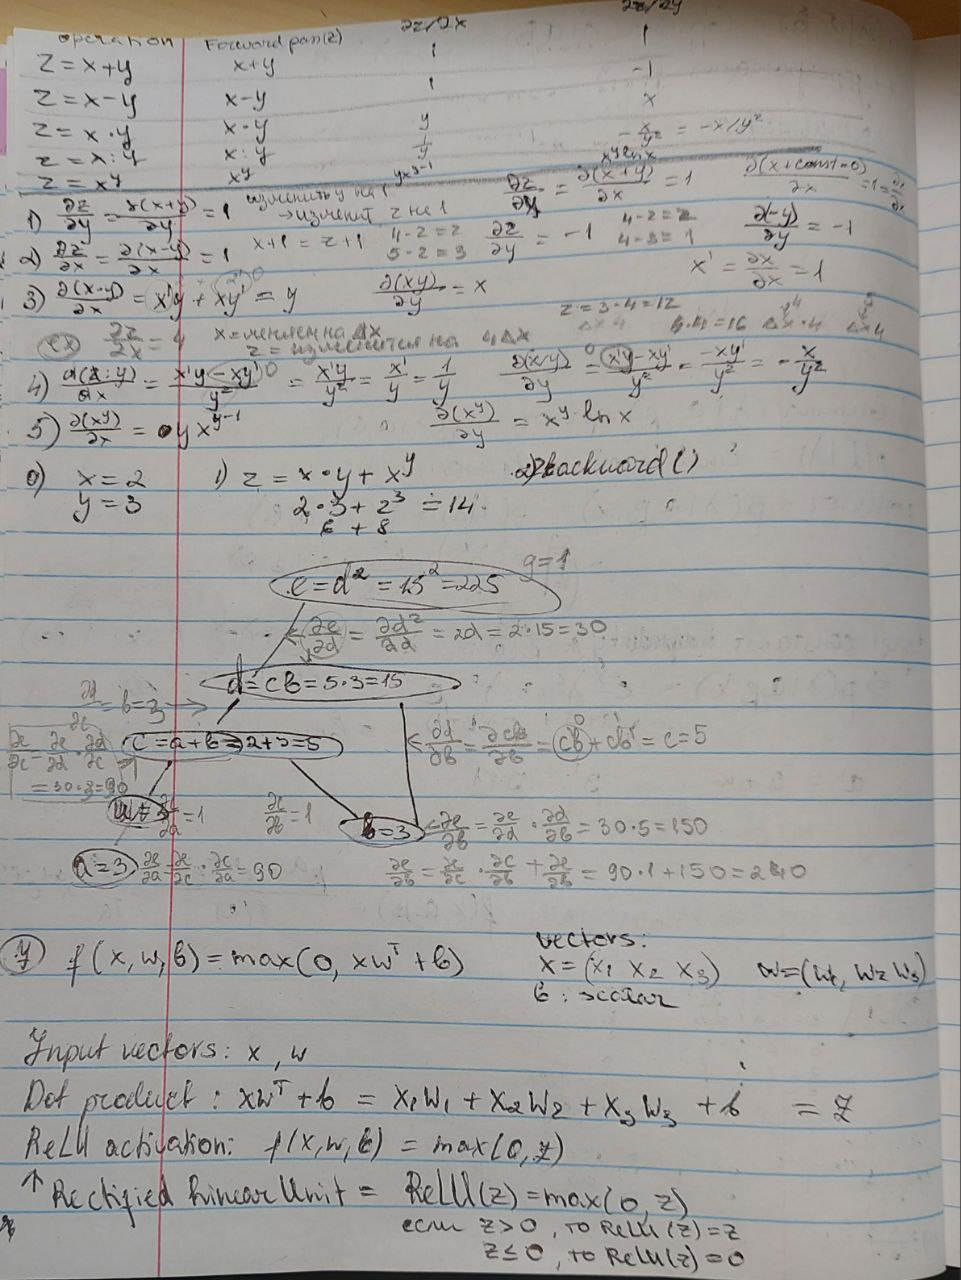

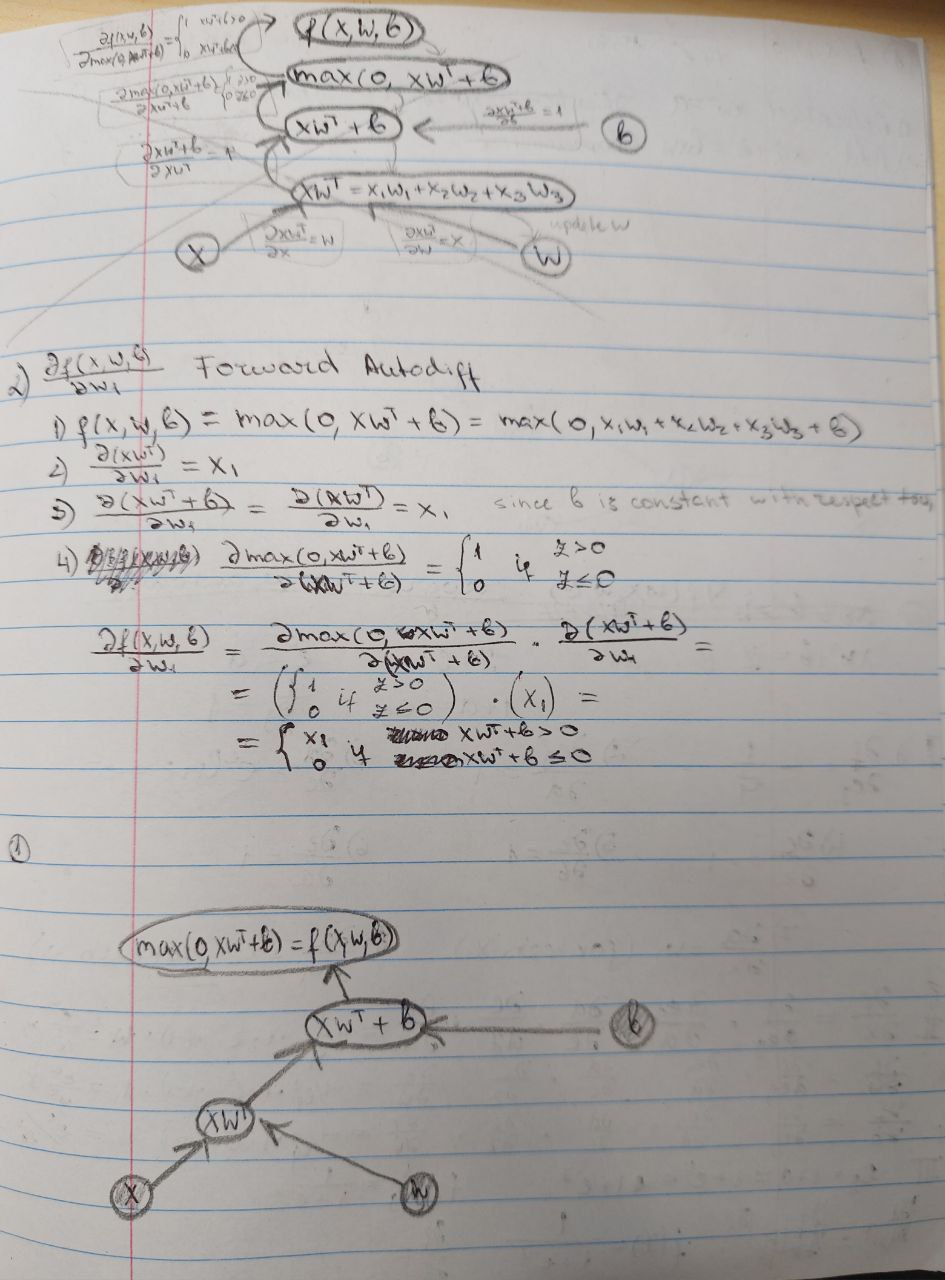Replace this line with your answer.

**ii) Answer:**

Replace this line with your answer.

# Question 8

Consider the function $f(\mathbf{x}, \mathbf{w}, b) = \frac{1}{1 + e^{-(\mathbf{x} \mathbf{w}^T + b)}}$, where $\mathbf{x} = [x_1, x_2, x_3]$ and $\mathbf{w} = [w_1, w_2, w_3]$ are vectors and $b$ is a scalar.

**i)** Construct the computational grapf of $f(\mathbf{x}, \mathbf{w}, b)$ (Hint: See last slides of the lecture).

**ii)** Find $\nabla f(\mathbf{x}, \mathbf{w}, b)$ with reverse-mode automatic differentiation.

**i) Answer:**

=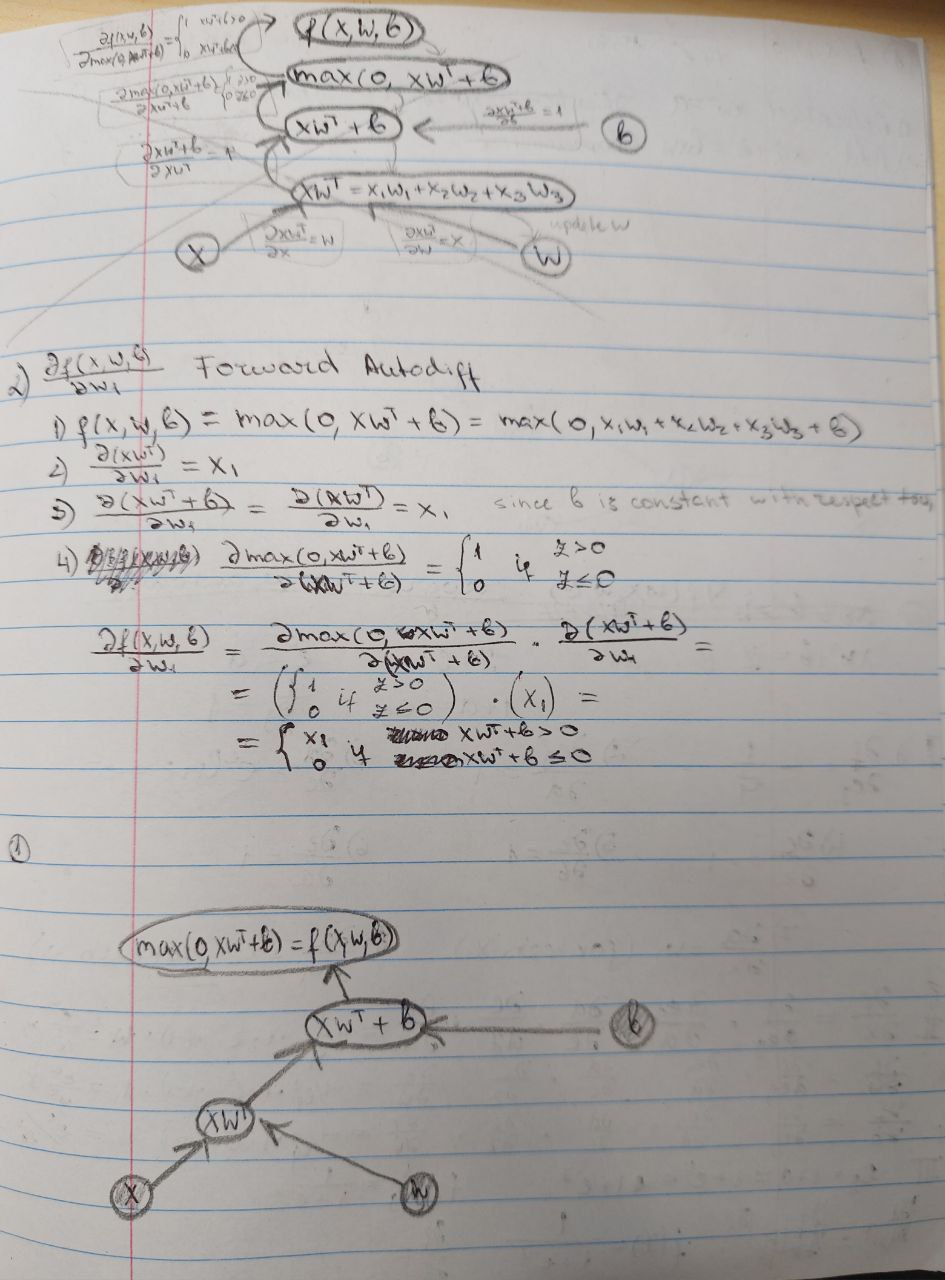
**ii) Answer:**

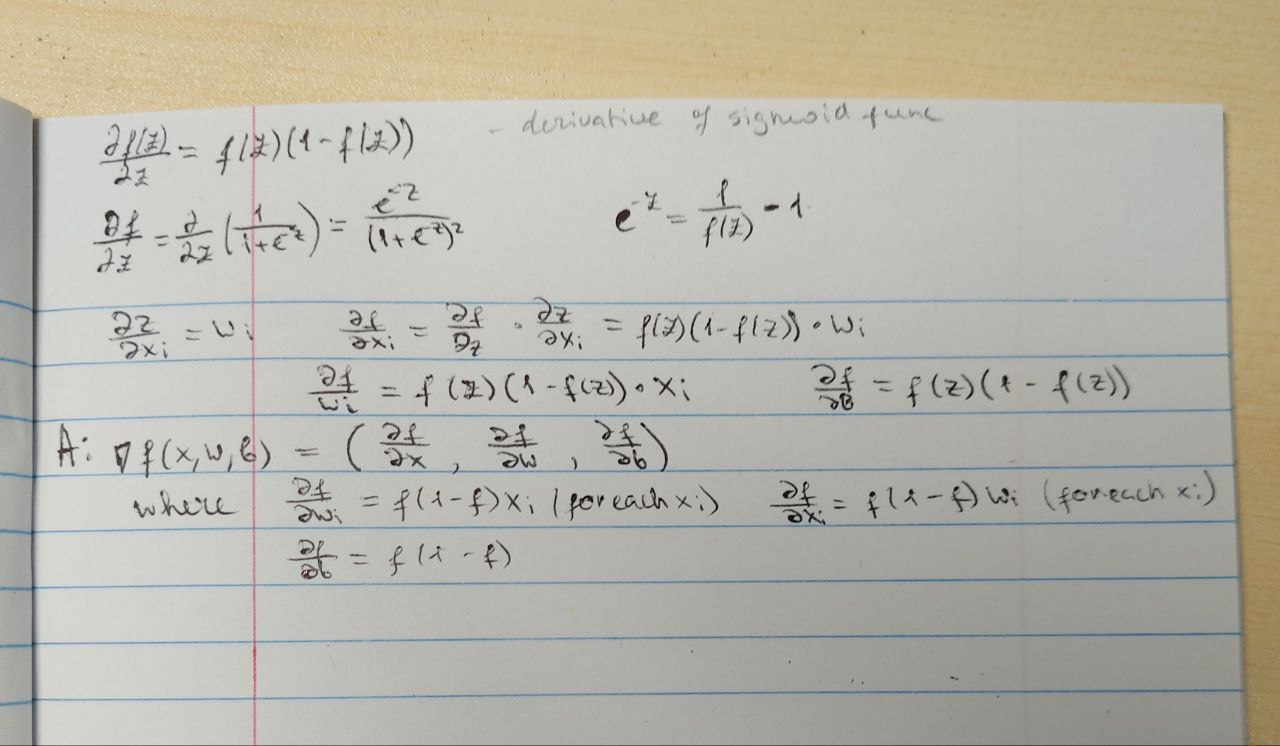

## Question 9 - Bonus

In [ ]:
# For extra practice, implement:
import math

class Variable:
    def __init__(self, data: float, edge=(), node=()):
        """
        Initialize a Variable object.

        Args:
            data (float): The value of the variable.
            edge (tuple, optional): Local derivatives with respect to the parents.
            node (tuple, optional): The parent nodes that created this variable.
        """
        self.data = float(data)  # Ensure data is a float
        self.edge = edge         # Local derivatives (computed during forward pass)
        self.node = node         # Parent nodes
        self.grad = 0.0          # Initialize gradient to zero

    def __repr__(self):
        """
        Return a string representation of the Variable, showing both value and gradient.
        """
        return f"Variable(data={self.data}, grad={self.grad})"

    def decorate(operator):
        """
        Decorator to handle the forward pass for all operations.
        """
        def wrapper(self, other):
            other = other if isinstance(other, self.__class__) else self.__class__(other)
            return self.__class__(*operator(self, other))
        return wrapper


    def sin(self):
      data = math.sin(self.data) # sin(x)
      edge = (math.cos(self.data),) # sin'(x) = cos(x)
      node = (self,)
      return data, edge, node and Variable(data, edge, (self,)) #Variable(data, edge, (self,)) to get not data=1, but data = 0.84 = sin(1)

    def exp(self):
        data = math.exp(self.data) # e(x)
        edge = (math.exp(self.data),)  # e'(x) = e(x)
        node = (self,)
        return data, edge, node and Variable(data, edge, (self,))


# Remember, you'd also create corresponding decorator calls.
# above
# Then test them with simple expressions to verify correctness.

x = Variable(1.0)  # Create a variable

sin_x = x.sin()  # Compute sin(x) and exp(x)
exp_x = x.exp()

# Perform forward pass
print("---- Forward Pass ----")
print(f"sin(x): {sin_x }")  # sin(1.0) ≈ 0.8415
print(f"exp(x): {exp_x}")  # exp(1.0) ≈ 2.7183
#output: sin(x=1), sin'(x=1)=cos(x=1),  Variable(data= sin(x=1),  grad=0.0)

---- Forward Pass ----
sin(x): (0.8414709848078965, (0.5403023058681398,), Variable(data=0.8414709848078965, grad=0.0))
exp(x): (2.718281828459045, (2.718281828459045,), Variable(data=2.718281828459045, grad=0.0))


## Wrapping Up

*   Make sure to provide clear derivations for the local gradients.
*   Thoroughly test your code with a variety of expressions.
*   Check that `zero_grad` prevents unwanted gradient accumulation.

Happy coding and learning about autodiff!